<h3><b>Data Analytics - Exercise set 5 - data processing and management</b></h3>

Put all your exercises (in Jupyter Notebook(s) ) in your course Git-project.<br /><br />
<span style="font-weight: bold;">Use either code comments or Jupyter Notebook markdown (text) to document which exercise you are doing and what a certain code section does!</span><br />

<span style="font-weight: bold;">Remember: your Jupyter notebook's clarity (how easy it is to read and understand) also affects your scoring!</span><br /><br />


<span style="font-weight: bold;">Remember also: 
<span style="font-weight: bold;">If you use generative AI in any part of any exercise, 
MENTION IT CLEARLY! </span><br />

**Regarding all exercises in this exercise set:**

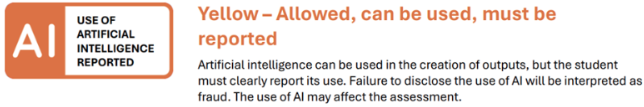


<span style="font-weight: bold;">(code comments are enough, also mention the purpose of the usage + how you are sure it works correctly).</span><br /><br />
See also the materials discussing the usage of AI in this course!</span><br /><br />


You can return all of these exercises in a single Jupyter Notebook, if you wish.

<p style="color: red;"><b>NOTE: The JSON/XML –files in Moodle in these exercises have been randomly generated. In other words, the data doesn't make any sense!</b></p>

In [1]:
import numpy as np
import pandas as pd
import json
import requests
from bs4 import BeautifulSoup

<h4><b>1. </b>Download <b>"simple.json"</b> in Moodle, and load it in pandas.</b> </h4>
<p>
The DataFrame should look like this:
</p>


<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex51.png" width="1000"/>

In [5]:
df_simple = pd.read_json('./exerciseset5_datafiles/simple.json')
df_simple

,id,brand,model,year,owned_by,acquired,price
0,1,Chrysler,Voyager,2001,Wolff-Trantow,28/12/2016,11565
1,2,Volkswagen,Jetta,1995,"Schuppe, Pfeffer and Klein",20/4/2016,52431
2,3,Porsche,Cayenne,2005,Mante Group,11/6/2020,75552
3,4,Porsche,928,1994,Wisozk Group,17/6/2019,30331
4,5,Mercedes-Benz,SL-Class,2007,Schiller-Littel,20/7/2018,62385
...,...,...,...,...,...,...,...
95,96,Dodge,Ram 1500 Club,2000,Schneider-Donnelly,28/9/2016,56256
96,97,GMC,Yukon XL 2500,2001,"Powlowski, Lemke and Wiza",19/4/2016,50163
97,98,Chevrolet,Sportvan G20,1992,"O'Keefe, Rogahn and Gleichner",1/6/2019,8577
98,99,Mitsubishi,3000GT,1993,Hoppe-Kunde,29/12/2018,23180


<h4><b>2.</b> Download <b>"simple.xml"</b> in Moodle, and load it in pandas</h4>
<p>
<span style="color: red"><b>(Note:</b> if using pandas.read_xml(), use also the xpath-parameter!)</span><br /><br >The Series should look something like this:
</p>


<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex52.png" />

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex52cars.jpg" width="600" />

In [7]:
df_xml = pd.read_xml('./exerciseset5_datafiles/simple.xml', xpath='/car')
df_xml

,id,brand,model,year,owned_by,acquired,price
0,1,Oldsmobile,Aurora,2003,"Herzog, Rodriguez and Howe",21/10/2016,32571


<h4><b>3. Load this API-data into a pandas DataFrame:</b></h4>
<p><a href="https://edu.frostbit.fi/api/events/en">https://edu.frostbit.fi/api/events/en</a></p>


<p>
Remember to use json_normalize to help you out with the categories and address information.<br /><b>Have address information in their own columns, and categories as separate rows.</b><br />The DataFrame should look something like this (note that the data changes daily, and exact values will vary):


</p>

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex53.png"/>

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex53events.jpg" width="600" />

In [8]:
# Using json_normalize so that:
#   - 'categories' becomes separate rows (record_path)
#   - address fields become separate columns (meta with nested keys)

response = requests.get('https://edu.frostbit.fi/api/events/en')
data = response.json()

df_events = pd.json_normalize(
    data,
    record_path=['categories'],
    meta=[
        'id', 'name', 'description',
        ['address', 'street_address'],
        ['address', 'locality'],
        ['address', 'postal_code']
    ],
    errors='ignore'
)

df_events

,0,id,name,description,address.street_address,address.locality,address.postal_code
0,dance (performing arts),NaN,Senioripaku Välkky in Iso Omena library,NaN,Suomenlahdentie 1,NaN,02230
1,health,NaN,Senioripaku Välkky in Iso Omena library,NaN,Suomenlahdentie 1,NaN,02230
2,libraries,NaN,Senioripaku Välkky in Iso Omena library,NaN,Suomenlahdentie 1,NaN,02230
3,literature,NaN,Senioripaku Välkky in Iso Omena library,NaN,Suomenlahdentie 1,NaN,02230
4,matinkylä,NaN,Senioripaku Välkky in Iso Omena library,NaN,Suomenlahdentie 1,NaN,02230
...,...,...,...,...,...,...,...
102,reading,NaN,Senioripaku Välkky in Soukantori,NaN,"Soukanraitti 5, 02360 Espoo",NaN,02360
103,soukka,NaN,Senioripaku Välkky in Soukantori,NaN,"Soukanraitti 5, 02360 Espoo",NaN,02360
104,theatre (art forms),NaN,Senioripaku Välkky in Soukantori,NaN,"Soukanraitti 5, 02360 Espoo",NaN,02360
105,well-being,NaN,Senioripaku Välkky in Soukantori,NaN,"Soukanraitti 5, 02360 Espoo",NaN,02360


<h4><b>4. Use web scraping (e.g. BeautifulSoup), and use it to get the following info from the Rovaniemi Wikipedia –page</b></h4>
<p><b>Wiki-page:</b> <a href="https://en.wikipedia.org/wiki/Rovaniemi">https://en.wikipedia.org/wiki/Rovaniemi</a></p>


<b>Tasks:</b>
<ul>
    <li>Get the coordinates of Rovaniemi (upper right corner)</li>
    <li>Get the nicknames of Rovaniemi (under coat of arms)</li>
</ul>

<b>Advanced extra tasks:</b>
<ul>
    <li><b>Get the total population</b></li>
    <ul>
        <li><b>Note:</b> this is a good example why webscraping can be tedious, since you'll have to traverse the HTML-tree to get what you want. This might be helpful:<br />
<a href="https://realpython.com/beautiful-soup-web-scraper-python/">https://realpython.com/beautiful-soup-web-scraper-python/</a></li>
    </ul>
    
</ul>

<ul>
    <li><b>Get the total area</b></li>
    <ul>
        <li>Convert this number into a float decimal (i.e. remove commas and the unit and call float() –in Python!)</li>
    </ul>
    
</ul>

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex54rovaniemi.jpg" width="600" />

In [9]:
# UserAgent header required because Wikipedia blocks requests without a browser identity
# I used AI to configure this header. 
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response = requests.get('https://en.wikipedia.org/wiki/Rovaniemi', headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

#Coordinates
coords_span = soup.find('span', class_='geo-dec')
print("Coordinates:", coords_span.text)

infobox = soup.find('table', class_='infobox')
if infobox is None:
    print("Infobox not found")
else:
    # Nicknames (under coat of arms)
    # I used AI to write the code to remove the citation numbers in brackets, e.g. [1] or [ 1 ] 
    import re
    nickname_td = next(
        (td for td in infobox.find_all('td') if 'Nickname' in td.get_text()),
        None
    )
    if nickname_td:
        full_text = nickname_td.get_text(separator=' ', strip=True)
        nicknames = full_text.replace('Nicknames:', '').strip()
        nicknames = re.sub(r'\[\s*\d+\s*\]', '', nicknames).strip()
        print("Nicknames:", nicknames)
    else:
        print("Nickname: Not found")

    # Advanced: Total population 
    in_population = False
    for row in infobox.find_all('tr'):
        row_text = row.get_text().lower()
        if 'population' in row_text:
            in_population = True
        if in_population and 'total' in row_text:
            td = row.find('td')
            if td:
                print("Population:", td.get_text(strip=True))
                break

    # Advanced: Total area
    in_area = False
    for row in infobox.find_all('tr'):
        row_text = row.get_text().lower()
        if 'area' in row_text:
            in_area = True
        if in_area and 'total' in row_text:
            td = row.find('td')
            if td:
                area_text = td.get_text(strip=True)
                # Remove commas and units.
                area_float = float(area_text.replace(',', '').split()[0])
                print("Area:", area_float, "km2")
                break

Coordinates: 66.500°N 25.733°E
Nicknames: Arctic Capital; Hometown of Santa Claus
Population: 66,191
Area: 8016.75 km2


<h4><b>5. Use web scraping, and create a DataFrame of this table: </b></h4>
<p> <a href="https://en.wikipedia.org/wiki/List_of_countries_by_average_yearly_temperature">https://en.wikipedia.org/wiki/List_of_countries_by_average_yearly_temperature</a></p>

<ul>
    <li>Change the name of the value column to "avg_temp" as well (pandas column rename)</li>
</ul>
<ul>
    <li><b>Small extra task: </b>clean up the column so that only the 
numeric °C-value is present (no other characters)
</li>
</ul>

<b>Advanced extra task:</b>
<ul>
    <li><b>Scrape these two tables as well</b></li>
    <ul>
        <li><a href="https://en.wikipedia.org/wiki/List_of_countries_by_employment_rate">https://en.wikipedia.org/wiki/List_of_countries_by_employment_rate</a></li>
        <li><a href="https://en.wikipedia.org/wiki/List_of_countries_by_unemployment_rate">https://en.wikipedia.org/wiki/List_of_countries_by_unemployment_rate</a></li>
    </ul>
    <br />
    <ul>
        <li><b>Combine the tables into a single DataFrame so that you get only the data of year 2020 or newer, and have the columns <span style="color: darkorange">"Country", "EmploymentRate"</span> and <span style="color: darkorange">"UnemploymentRate"</span>. You can also create additional columns <span style="color: red">"EmploymentRate15_24"</span>and <span style="color: red">"EmploymentRate25_70"</span> if you scrape the OECD-table as well! </b>

</li>
    </ul>
</ul>

In [10]:
import io

# UserAgent header required because Wikipedia blocks requests without a browser identity
# I used AI to configure this header.
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}
response = requests.get(
    'https://en.wikipedia.org/wiki/List_of_countries_by_average_yearly_temperature',
    headers=headers
)

soup = BeautifulSoup(response.text, 'html.parser')
table = soup.find('table', class_='wikitable')
if table is not None:
    df_temp = pd.read_html(io.StringIO(str(table)))[0]
else:
    df_temp = pd.read_html(io.StringIO(response.text), attrs={'class': 'wikitable'})[0]

df_temp = df_temp.iloc[:, [1, -1]].copy()
df_temp.columns = ['Country', 'avg_temp']

df_temp['avg_temp'] = df_temp['avg_temp'].astype(str).str.extract(r'([-\d.]+)')[0].astype(float)

df_temp

,Country,avg_temp
0,Burkina Faso,30.40
1,Mali,29.21
2,Aruba,29.17
3,Senegal,28.90
4,Mauritania,28.82
...,...,...
230,Mongolia,1.07
231,Russia,3.79
232,Canada,4.03
233,Svalbard and Jan Mayen,6.78


<h4><b>6. Simple merging:</b> Download <u><b>coffee_sales.csv</b></u> and <b><u>temperatures_fixed.csv</u></b> from Moodle.<b></h4>
<p>Use merging to combine these files into one DataFrame, containing the coffee sales data and the corresponding temperature –data. (merge(), see materials for examples)</p>


<span style="color: red;"><b>Use left join, and coffee sales as the first DataFrame!</b></span>

In [12]:
coffee = pd.read_csv('./exerciseset5_datafiles/coffee_sales.csv')
temps_fixed = pd.read_csv('./exerciseset5_datafiles/temperatures_fixed.csv')

# Merge on the Date column using a left join
merged = pd.merge(coffee, temps_fixed, on='Date', how='left')
merged

,Date,Sales,Target_sales,Total_expenses,Temperature (C)
0,1.10.2012,122,90,76,19.822917
1,1.10.2012,123,90,45,19.822917
2,2.10.2012,107,90,36,19.020602
3,3.10.2012,94,100,21,15.820139
4,4.10.2012,182,80,54,15.110648
...,...,...,...,...,...
1057,23.8.2015,534,360,94,18.253009
1058,24.8.2015,236,160,60,21.114583
1059,25.8.2015,33,0,145,22.575000
1060,26.8.2015,341,230,65,20.204398


<b>Extra task: </b> Do the same but with <b>temperatures_unfixed.csv</b> instead. Remember <b>groupby()</b> before attempting merging! 

<b>Also, you might want to remove some of the columns before grouping data => <span style="color: red;">Summary + Hour</span>. </b>

<span><i>You can also try to merge the DataFrames so that the Summary –of the weather is also added. For this, you probably need to figure out first how to determine the "average" Summary for each day (extra challenge!).</i></span>


In [13]:
temps_unfixed = pd.read_csv('./exerciseset5_datafiles/temperatures_unfixed.csv')

# Remove Summary and Hour columns before groupby, then average temperature per day
temps_daily = (temps_unfixed
               .drop(columns=['Summary', 'Hour'])
               .groupby('Date', as_index=False)
               .mean())

merged_unfixed = pd.merge(coffee, temps_daily, on='Date', how='left')
merged_unfixed

,Date,Sales,Target_sales,Total_expenses,Temperature (C)
0,1.10.2012,122,90,76,19.822917
1,1.10.2012,123,90,45,19.822917
2,2.10.2012,107,90,36,19.020602
3,3.10.2012,94,100,21,15.820139
4,4.10.2012,182,80,54,15.110648
...,...,...,...,...,...
1057,23.8.2015,534,360,94,18.253009
1058,24.8.2015,236,160,60,21.114583
1059,25.8.2015,33,0,145,22.575000
1060,26.8.2015,341,230,65,20.204398


<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex56coffee.jpg" width="450" />


<h2><b>Advanced extra tasks for extra points (varying challenges, some require Googling):</b></h2>

<ul>
<li><b>1. Download the "complex.json" –file from Moodle.</b> Note that this data is fairly complex (i.e. heavily nested). Use json_normalize and other needed methods to convert this data into a workable DataFrame.</li>
</ul>

In [15]:
with open('./exerciseset5_datafiles/complex.json', 'r') as f:
    complex_data = json.load(f)

df_complex_json = pd.json_normalize(complex_data)
df_complex_json

,id,brand,model,year,price,ownership.company,ownership.acquired,ownership.payment_info.credit_card,ownership.payment_info.iban
0,1,Ford,F250,1997,72213,Johns and Sons,24/10/2017,jcb,SA47 315V KYTA 8FVT NCGN MM7G
1,2,Dodge,Grand Caravan,1999,42370,"Crist, Hyatt and Leannon",7/6/2020,instapayment,FR74 8157 1767 53I2 VRAN ZMIB U11
2,3,Audi,A5,2011,19191,Bosco and Sons,23/11/2018,jcb,LB32 4989 VCVZ S5BZ X2CT JKG3 QRAW
3,4,Hyundai,Veracruz,2012,21956,Haley Inc,5/6/2016,bankcard,BE62 4961 0596 5774
4,5,Chevrolet,TrailBlazer,2009,53066,"Zulauf, Nolan and Franecki",14/1/2021,jcb,FR11 1768 5506 10IU QVPN XU2H O88
...,...,...,...,...,...,...,...,...,...
95,96,Hyundai,Elantra,1997,38400,Keebler and Sons,26/6/2019,visa-electron,RS34 1571 2547 8662 4201 18
96,97,Mercury,Grand Marquis,1996,27284,Wunsch-Ernser,9/11/2019,mastercard,AD85 4944 9836 X0YY JZAF NIXH
97,98,GMC,Safari,1996,17723,Ondricka-Schuster,17/7/2016,jcb,FR22 8203 4892 75GI 8YFM NAXR B47
98,99,Dodge,Ram Van 1500,2000,32892,Heathcote-Gleichner,21/4/2016,jcb,SA43 49ZA FH7V 20XN BYDW ROEX


<ul>
<li><b>2. Load the "simple.json" –file without pandas, and try to get the average price with plain Python. <b>(DON'T USE AI HERE)</b></li>
</ul>

In [16]:
with open('./exerciseset5_datafiles/simple.json', 'r') as f:
    cars = json.load(f)

total_price = 0
for car in cars:
    total_price += car['price']

average_price = total_price / len(cars)

print(f"Average price  : {average_price}")

Average price  : 42373.86


<ul>
<li><b>3. Download the "complex.xml" file from Moodle, and create a DataFrame out of it.</b></li>
<ul>
    <li><b>Note:</b> using pandas.read_xml() would otherwise work, but it ignores the "ownership" –field. You'll have to find another way to get this data into your DataFrame as well!</li>
</ul>
</ul>

In [18]:
# pd.read_xml() only parses one level deep, so nested ownership is ignored.
# xml.etree.ElementTree manually traverse all nested elements.

import xml.etree.ElementTree as ET

tree = ET.parse('./exerciseset5_datafiles/complex.xml')
root = tree.getroot()

records = []
for car in root.findall('car'):
    record = {
        'id':    int(car.findtext('id')),
        'brand': car.findtext('brand'),
        'model': car.findtext('model'),
        'year':  int(car.findtext('year')),
        'price': int(car.findtext('price')),
    }
    ownership = car.find('ownership')
    if ownership is not None:
        record['company']  = ownership.findtext('company')
        record['acquired'] = ownership.findtext('acquired')
        payment = ownership.find('payment_info')
        if payment is not None:
            record['credit_card'] = payment.findtext('credit_card')
            record['iban']        = payment.findtext('iban')
    records.append(record)

df_complex_xml = pd.DataFrame(records)
df_complex_xml

,id,brand,model,year,price,company,acquired,credit_card,iban
0,1,Mazda,B-Series Plus,1994,69221,Mueller-VonRueden,25/3/2020,jcb,LU43 964Q PJUD Z9WI JVSR
1,2,Ford,F350,2006,13859,"Simonis, Graham and Veum",6/4/2020,diners-club-enroute,AE82 5889 6103 2911 2983 729
2,3,BMW,7 Series,2012,78125,Hammes LLC,25/12/2017,jcb,AZ52 PNUH TWPT YQY9 RMLE BMXO 4JIT
3,4,Subaru,Baja,2004,32941,"MacGyver, Oberbrunner and McGlynn",2/6/2019,mastercard,FR22 5863 0754 268V RGIQ GHX5 Y27
4,5,Audi,S6,2007,46761,"Hand, Johnston and Hickle",12/10/2016,jcb,LT37 9834 6062 9512 0523
...,...,...,...,...,...,...,...,...,...
95,96,Lexus,IS,2004,79409,Lesch LLC,24/12/2018,jcb,FR64 3740 9590 01ZO OCUS 3G4U N18
96,97,Oldsmobile,Bravada,2001,61308,Swaniawski-Fahey,31/3/2021,switch,FR20 8397 0045 00LM TIZG K8XG Y85
97,98,Dodge,Ram 2500 Club,1996,12101,"Boyle, Bins and Hand",14/2/2017,instapayment,LT97 1330 9495 1788 8021
98,99,Jeep,Wrangler,2007,74912,Frami and Sons,1/1/2019,americanexpress,FR29 9014 0050 39DG BF8H M8BB R59


<ul>
    <li><b>4. Try out Selenium on a site that cannot be scraped with traditional methods. You can use this tutorial as the starting point:</b></li>
    <ul>
        <li><a href="https://www.toptal.com/python/web-scraping-with-python">https://www.toptal.com/python/web-scraping-with-python</a></li>
    </ul>
</ul>

In [ ]:
# code for the advanced extra task, you can also create a separate notebook for this 
# (might be a better idea, since a new dataset always adds quite much new code)

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex5charts.jpg" width="600" />

<b>5. Extra challenging advanced task: <span style="color: red;">integrating data sources</span></b>

<ul>
<li><b>Integrate two or more datasets into one matching dataset (pandas DataFrame), but use any datasets you can find in Kaggle.com instead of the previous coffee sales + temperature -datasets</b></li>
<br />
<ul>
<li>Find two or more datasets (Kaggle.com etc.) that have something in common and can be used for merging. </li>
</ul>

<br />
<ul>
<li><b>Typical common columns:</b></li>
<ul>
<li>Coordinates (lat/lng etc.)</li>
<li>Years, months</li>
<li>reference ids (e.g. product id -> product data)</li>
</ul>
</ul>

<br />
<ul>
<li><b>You can use pandas.merge() in order to combine DataFrames</b></li>
<ul>
<li>When combining DataFrames, make sure that the merge doesn’t mess up your data</li>
<li><b>Note:</b> merge can often create way too many extra rows depending on the merging parameters</li>

</ul>
</ul>

<br />
<ul>
<li><b>This exercise can provide even large amounts of points, depending on difficulty. Aspects that affect grading:</b></li>
<ul>
<li>Amount of datasets</li>
<li>Difficulty of the datasets</li>
<li>Using different data formats all at once (XML, JSON, CSV etc.)</li>
<li>Other techniques used to add data: web scraping, data APIs etc.</li>
</ul>
</ul>


</ul>

In [ ]:
# this exercise is probably better to do in a separate Jupyter notebook